# Getting Started

## First STLDriver object

In [1]:
import stlrom as stl
d = stl.STLDriver()
d.parse_string('signal x,y')
print(d)

# STLDriver object defined as
signal x, y

# With formulas

# Data:
No data yet.


## Adding signal data

In [2]:
d.add_sample([0, 0.1, 0.2])
d.add_sample([0.5, -0.1, -0.2])
d.add_sample([1, 0, 0])
print(d)

# STLDriver object defined as
signal x, y

# With formulas

# Data:

# Signal x:
3 samples from t0=0 to t_end=1

# Signal y:
3 samples from t0=0 to t_end=1



## First Plots

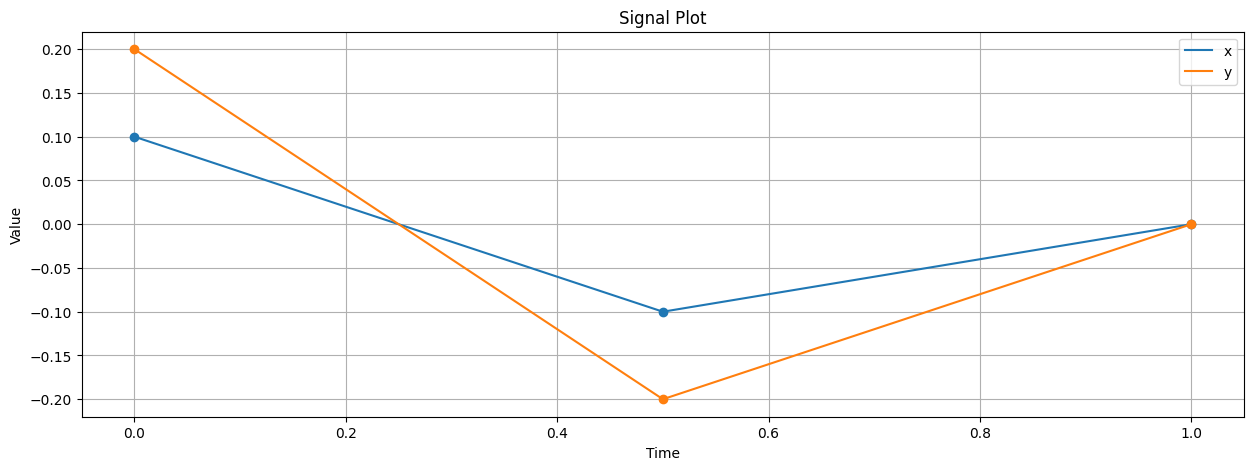

In [3]:
ax = d.plot_signal('x')  # plots signal x, returns axis
ax = d.plot_signal('y',ax=ax) # plots signal y on the same axis

## First Predicates

In [4]:
d.parse_string("""
mu_x    := x[t]>0
mu_y    := y[t]>0
mu_comp := x[t]<y[t]
""")
print(d)

# STLDriver object defined as
signal x, y

# With formulas
mu_comp:= x[t] < y[t]
mu_x:= x[t] > 0
mu_y:= y[t] > 0

# Data:

# Signal x:
3 samples from t0=0 to t_end=1

# Signal y:
3 samples from t0=0 to t_end=1



In [5]:
d.set_semantics('BOOLEAN')
r_mu = d.eval_rob('mu_x',0,1)
print(r_mu)

begin_time: 0  end_time: 1
time:          0  value:          1  derivative:          0
time:       0.25  value:          0  derivative:          0



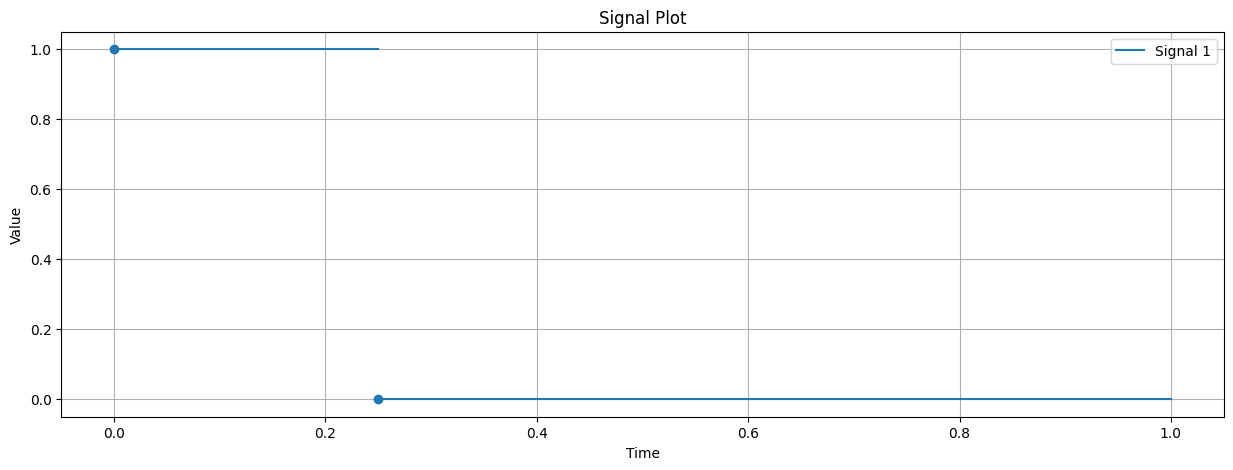

In [6]:
r_mu.plot();

In [7]:
d.parse_string("mu_eq := x[t] == 0")
d.parse_string("mu_ev := ev_[0, 0.1] mu_eq")
print(d)

# STLDriver object defined as
signal x, y

# With formulas
mu_comp:= x[t] < y[t]
mu_eq:= x[t] == 0
mu_ev:= ev_[0,0.1] (x[t] == 0) 
mu_x:= x[t] > 0
mu_y:= y[t] > 0

# Data:

# Signal x:
3 samples from t0=0 to t_end=1

# Signal y:
3 samples from t0=0 to t_end=1



In [ ]:
r_mu_ev = d.eval_rob('mu_ev', 0, 0.9) #TODO: time horizon (eventually adds length to x)
rob_map = d.get_robustness_map('mu_ev')

stl.plot_rob_map_widget(rob_map)

interactive(children=(Dropdown(description='Robustness:', options=(('Robustness', 'z'), ('Lower', 'z_low'), ('…

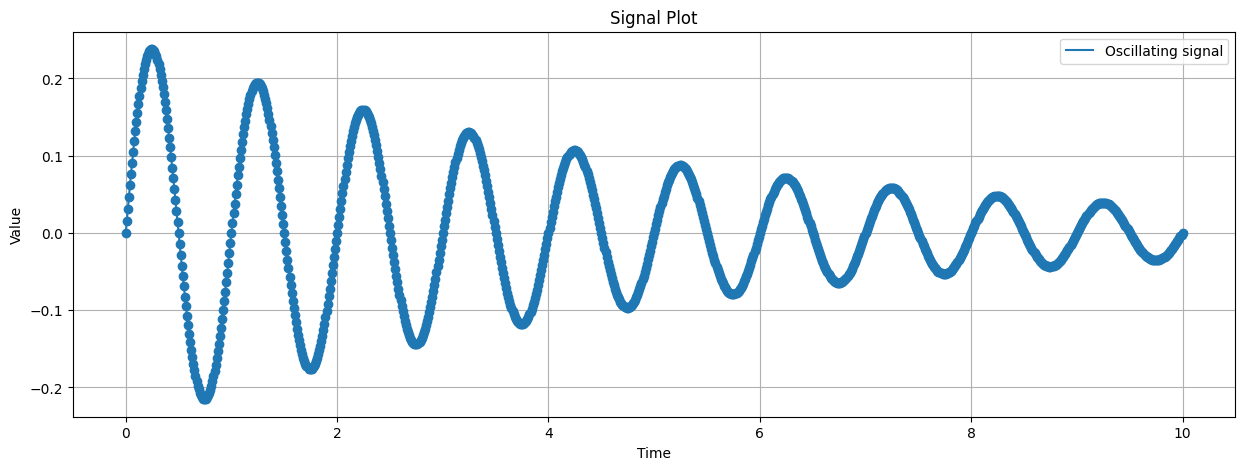

In [19]:
from stlrom import OscillSignalGen

osc_gen = OscillSignalGen(period=1, amplitude=0.25, base=0, damp=-0.2)
osc_signal = osc_gen.get_signal(t0=0, tf=10, dt=0.01)
osc_signal.plot(label='Oscillating signal');


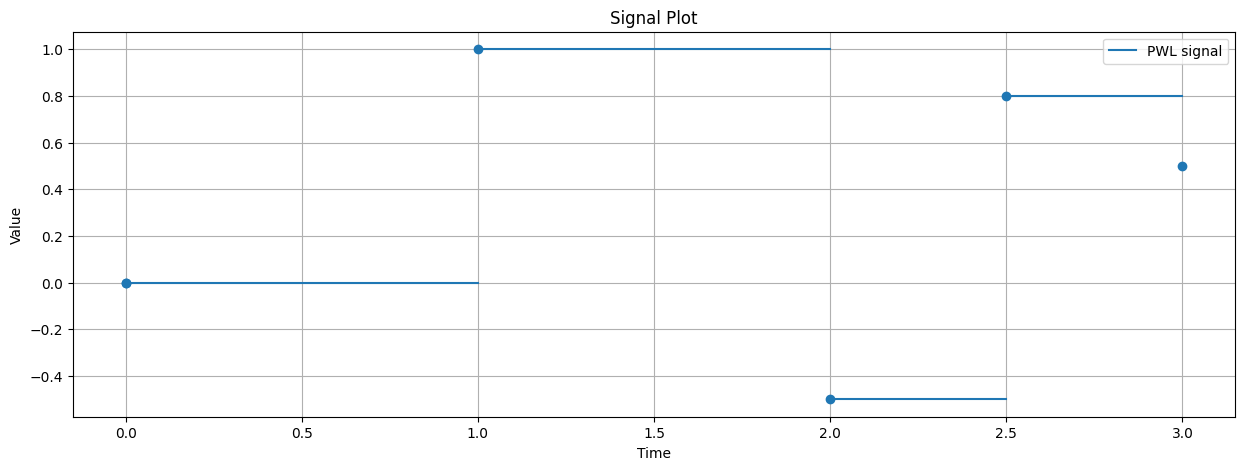

In [ ]:
from stlrom import PWLSignalGen

pwl_gen = PWLSignalGen(times=[0, 1., 2., 2.5, 3.], values=[0., 1., -0.5, 0.8, 0.5])
pwl_signal = pwl_gen.get_signal(t0=0, tf=3)
pwl_signal.plot(label='PWL signal');